In [1]:
import sys
import json
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import wandb

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device    :", device)

PyTorch version : 2.12.0+cpu
CUDA available  : False
Using device    : cpu


In [2]:
# ── Paths ────────────────────────────────────────────────────
BASE_DIR  = Path(r"C:\Users\ishas\OneDrive\Desktop\ML\Ecolens")
DATA_DIR  = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# ── Load class labels ────────────────────────────────────────
with open(DATA_DIR / "class_labels.json") as f:
    CLASS_TAXONOMY = json.load(f)

# class name → integer index (for model output)
CLASS_NAMES  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

# ── Training hyperparameters ─────────────────────────────────
CONFIG = {
    "img_size"        : 224,    # EfficientNet input size
    "batch_size"      : 32,     # images per training step
    "num_epochs"      : 15,     # training rounds
    "learning_rate"   : 1e-4,   # how fast weights update
    "num_classes"     : len(CLASS_NAMES),
    "model_name"      : "efficientnet_b4",
    "dropout"         : 0.4,
}

print("Classes found:", CLASS_NAMES)
print("Num classes  :", CONFIG["num_classes"])
print("Class → idx  :", CLASS_TO_IDX)
print("\nConfig:")
for k, v in CONFIG.items():
    print(f"  {k:<18} {v}")

Classes found: ['glass', 'hazardous', 'metal', 'non_recyclable_trash', 'organic_biodegradable', 'paper_cardboard', 'recyclable_plastic']
Num classes  : 7
Class → idx  : {'glass': 0, 'hazardous': 1, 'metal': 2, 'non_recyclable_trash': 3, 'organic_biodegradable': 4, 'paper_cardboard': 5, 'recyclable_plastic': 6}

Config:
  img_size           224
  batch_size         32
  num_epochs         15
  learning_rate      0.0001
  num_classes        7
  model_name         efficientnet_b4
  dropout            0.4


In [3]:
IMG_SIZE = CONFIG["img_size"]

# Applied to training images — random augmentation every time
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=15, p=0.4),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10,
        p=0.3
    ),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.CoarseDropout(
        max_holes=8,
        max_height=16,
        max_width=16,
        fill_value=0,
        p=0.2
    ),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

# Applied to val/test — only resize and normalize, no augmentation
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print("Train transforms:")
for t in train_transforms.transforms:
    print(f"  {t.__class__.__name__}")

print("\nVal transforms:")
for t in val_transforms.transforms:
    print(f"  {t.__class__.__name__}")

Train transforms:
  Resize
  HorizontalFlip
  VerticalFlip
  Rotate
  RandomBrightnessContrast
  HueSaturationValue
  GaussianBlur
  CoarseDropout
  Normalize
  ToTensorV2

Val transforms:
  Resize
  Normalize
  ToTensorV2


C:\Users\ishas\AppData\Local\Temp\ipykernel_47480\3816218079.py:21: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [4]:
class WasteDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, class_to_idx, transform=None):
        self.data_dir     = Path(data_dir)
        self.transform    = transform
        self.class_to_idx = class_to_idx
        self.valid_ext    = {'.jpg','.jpeg','.png',
                             '.JPG','.JPEG','.PNG'}
        self.samples = []

        for class_folder in sorted(self.data_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            if class_folder.name not in class_to_idx:
                continue
            label = class_to_idx[class_folder.name]
            for img_path in class_folder.iterdir():
                if img_path.suffix in self.valid_ext:
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(str(img_path)).convert("RGB")
        image = np.array(image)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, label

    def get_labels(self):
        return [label for _, label in self.samples]

# Quick test
test_ds = WasteDataset(TRAIN_DIR, CLASS_TO_IDX, transform=val_transforms)
img, label = test_ds[0]
print(f"Dataset size     : {len(test_ds)}")
print(f"Sample image shape: {img.shape}")
print(f"Sample label      : {label} → {IDX_TO_CLASS[label]}")
print(f"Image dtype       : {img.dtype}")
print(f"Image min/max     : {img.min():.3f} / {img.max():.3f}")

Dataset size     : 10302
Sample image shape: torch.Size([3, 224, 224])
Sample label      : 0 → glass
Image dtype       : torch.float32
Image min/max     : -2.118 / 2.640


In [5]:
def make_weighted_sampler(dataset):
    labels       = dataset.get_labels()
    class_counts = Counter(labels)

    # Rare classes get higher weight
    class_weights  = {cls: 1.0/count for cls, count in class_counts.items()}
    sample_weights = [class_weights[l] for l in labels]
    sample_weights = torch.DoubleTensor(sample_weights)

    return WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True
    )

# Build datasets
train_dataset = WasteDataset(TRAIN_DIR, CLASS_TO_IDX, transform=train_transforms)
val_dataset   = WasteDataset(VAL_DIR,   CLASS_TO_IDX, transform=val_transforms)
test_dataset  = WasteDataset(TEST_DIR,  CLASS_TO_IDX, transform=val_transforms)

# Build sampler
train_sampler = make_weighted_sampler(train_dataset)

# Build DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG["batch_size"],
    sampler     = train_sampler,
    num_workers = 0,
    pin_memory  = False
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = 0
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = 0
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch size    : {CONFIG['batch_size']}")
print(f"\nClass weights (higher = sampled more often):")
labels       = train_dataset.get_labels()
class_counts = Counter(labels)
for cls_idx, count in sorted(class_counts.items()):
    cls_name = IDX_TO_CLASS[cls_idx]
    weight   = 1.0 / count
    print(f"  {cls_name:<25} count={count:>5}  weight={weight:.6f}")

Train batches : 322
Val batches   : 65
Test batches  : 44
Batch size    : 32

Class weights (higher = sampled more often):
  glass                     count= 1884  weight=0.000531
  hazardous                 count=  708  weight=0.001412
  metal                     count=  884  weight=0.001131
  non_recyclable_trash      count= 2875  weight=0.000348
  organic_biodegradable     count=  738  weight=0.001355
  paper_cardboard           count= 2203  weight=0.000454
  recyclable_plastic        count= 1010  weight=0.000990


In [6]:
def build_model(num_classes, dropout=0.4):
    # Load EfficientNet-B4 with ImageNet pretrained weights
    model = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
    )

    # Freeze ALL pretrained layers first
    # These layers already know how to detect edges, textures, shapes
    for param in model.parameters():
        param.requires_grad = False

    # Replace only the final classifier head
    # Original head outputs 1000 ImageNet classes
    # We replace it with our 7-class head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )

    # Unfreeze the last 2 blocks of EfficientNet features
    # This lets the model fine-tune high-level features for waste
    for param in model.features[6:].parameters():
        param.requires_grad = True

    total_params    = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                          if p.requires_grad)

    print(f"Model         : EfficientNet-B4")
    print(f"Total params  : {total_params:,}")
    print(f"Trainable     : {trainable_params:,}")
    print(f"Frozen        : {total_params - trainable_params:,}")
    print(f"Output classes: {num_classes}")

    return model

model = build_model(CONFIG["num_classes"], CONFIG["dropout"])
model = model.to(device)
print(f"\nModel moved to: {device}")

Model         : EfficientNet-B4
Total params  : 17,561,167
Trainable     : 13,925,183
Frozen        : 3,635,984
Output classes: 7

Model moved to: cpu


In [7]:
# Loss function — CrossEntropyLoss for multi-class classification
# It measures how wrong the model's predictions are
criterion = nn.CrossEntropyLoss()

# Optimizer — Adam with different learning rates
# Lower LR for pretrained layers (don't disturb learned features much)
# Higher LR for new classifier head (needs to learn from scratch)
optimizer = optim.Adam([
    {
        'params': model.features[6:].parameters(),
        'lr'    : CONFIG["learning_rate"] / 10   # 1e-5 for pretrained layers
    },
    {
        'params': model.classifier.parameters(),
        'lr'    : CONFIG["learning_rate"]         # 1e-4 for new head
    }
])

# Learning rate scheduler — reduces LR when val loss stops improving
# This helps the model converge to a better solution
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',    # reduce when val_loss stops decreasing
    factor   = 0.5,      # multiply LR by 0.5
    patience = 3,        # wait 3 epochs before reducing
)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print(f"LR (features) : {CONFIG['learning_rate']/10}")
print(f"LR (classifier): {CONFIG['learning_rate']}")
print("Scheduler     : ReduceLROnPlateau (patience=3, factor=0.5)")

Loss function : CrossEntropyLoss
Optimizer     : Adam
LR (features) : 1e-05
LR (classifier): 0.0001
Scheduler     : ReduceLROnPlateau (patience=3, factor=0.5)


In [8]:

# Manual experiment tracker — replaces W&B
# Saves all metrics to a JSON file instead

import json
from datetime import datetime

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

experiment_log = {
    "run_id"    : run_id,
    "model"     : CONFIG["model_name"],
    "config"    : CONFIG,
    "epochs"    : [],
    "best_val_acc" : 0.0
}

LOG_FILE = MODEL_DIR / f"experiment_{run_id}.json"

def log_epoch(epoch, train_loss, train_acc, val_loss, val_acc, lr):
    """Save epoch metrics to JSON file"""
    epoch_data = {
        "epoch"      : epoch,
        "train_loss" : round(train_loss, 4),
        "train_acc"  : round(train_acc, 2),
        "val_loss"   : round(val_loss, 4),
        "val_acc"    : round(val_acc, 2),
        "lr"         : lr
    }
    experiment_log["epochs"].append(epoch_data)

    with open(LOG_FILE, "w") as f:
        json.dump(experiment_log, f, indent=2)

print(f"Experiment tracker ready")
print(f"Run ID    : {run_id}")
print(f"Log file  : {LOG_FILE}")
print("All metrics will be saved to JSON after each epoch")


Experiment tracker ready
Run ID    : 20260518_194255
Log file  : C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\experiment_20260518_194255.json
All metrics will be saved to JSON after each epoch


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"Loss: {running_loss/(batch_idx+1):.4f} "
                  f"Acc: {100.*correct/total:.2f}%")

    return running_loss / len(loader), 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

print("train_one_epoch defined")
print("validate defined")
print("Ready — now run Cell 10 to start training!")

train_one_epoch defined
validate defined
Ready — now run Cell 10 to start training!


In [11]:
best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : []
}

print("Starting training...")
print(f"Epochs     : {CONFIG['num_epochs']}")
print(f"Device     : {device}")
print(f"Batch size : {CONFIG['batch_size']}")
print(f"Classes    : {CONFIG['num_classes']}")
print("=" * 60)

for epoch in range(CONFIG["num_epochs"]):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']

    # Log to JSON file
    log_epoch(
        epoch    = epoch + 1,
        train_loss = train_loss,
        train_acc  = train_acc,
        val_loss   = val_loss,
        val_acc    = val_acc,
        lr         = current_lr
    )

    elapsed = time.time() - start
    print(f"\nEpoch [{epoch+1:02d}/{CONFIG['num_epochs']}] "
          f"({elapsed:.0f}s)")
    print(f"  Train → Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")
    print(f"  Val   → Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")
    print(f"  LR    → {current_lr:.2e}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        experiment_log["best_val_acc"] = best_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(
            {
                'epoch'       : epoch + 1,
                'model_state' : best_model_wts,
                'val_acc'     : best_val_acc,
                'config'      : CONFIG,
                'class_to_idx': CLASS_TO_IDX
            },
            MODEL_DIR / "best_model.pth"
        )
        print(f"  Best model saved! Val Acc: {val_acc:.2f}%")

print("\n" + "=" * 60)
print("Training complete!")
print(f"Best Val Accuracy : {best_val_acc:.2f}%")
print(f"Model saved to    : {MODEL_DIR / 'best_model.pth'}")
print(f"Experiment log    : {LOG_FILE}")

Starting training...
Epochs     : 15
Device     : cpu
Batch size : 32
Classes    : 7
  Batch 50/322 Loss: 1.9223 Acc: 22.81%
  Batch 100/322 Loss: 1.8875 Acc: 34.19%
  Batch 150/322 Loss: 1.8494 Acc: 43.67%
  Batch 200/322 Loss: 1.8113 Acc: 49.70%
  Batch 250/322 Loss: 1.7686 Acc: 54.05%
  Batch 300/322 Loss: 1.7224 Acc: 57.48%

Epoch [01/15] (2664s)
  Train → Loss: 1.7000  Acc: 58.64%
  Val   → Loss: 1.4000  Acc: 82.89%
  LR    → 1.00e-05
  Best model saved! Val Acc: 82.89%
  Batch 50/322 Loss: 1.2923 Acc: 78.56%
  Batch 100/322 Loss: 1.2294 Acc: 77.53%
  Batch 150/322 Loss: 1.1665 Acc: 77.83%
  Batch 200/322 Loss: 1.1051 Acc: 78.08%
  Batch 250/322 Loss: 1.0468 Acc: 78.71%
  Batch 300/322 Loss: 0.9996 Acc: 78.67%

Epoch [02/15] (1735s)
  Train → Loss: 0.9769  Acc: 78.97%
  Val   → Loss: 0.6669  Acc: 84.78%
  LR    → 1.00e-05
  Best model saved! Val Acc: 84.78%
  Batch 50/322 Loss: 0.6641 Acc: 81.31%
  Batch 100/322 Loss: 0.6413 Acc: 81.88%
  Batch 150/322 Loss: 0.6172 Acc: 82.54%
  B

KeyboardInterrupt: 

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR  = Path(r"C:\Users\ishas\OneDrive\Desktop\ML\Ecolens")
DATA_DIR  = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"
MODEL_DIR = BASE_DIR / "models"

CLASS_NAMES  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print("Device     :", device)
print("MODEL_DIR  :", MODEL_DIR)
print("Classes    :", CLASS_NAMES)
print("All setup done!")

Device     : cpu
MODEL_DIR  : C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models
Classes    : ['glass', 'hazardous', 'metal', 'non_recyclable_trash', 'organic_biodegradable', 'paper_cardboard', 'recyclable_plastic']
All setup done!


In [3]:
def build_model(num_classes=7, dropout=0.4):
    model = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
    )
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

checkpoint_path = MODEL_DIR / "best_model.pth"
print("File exists:", checkpoint_path.exists())
print("File size  :", round(checkpoint_path.stat().st_size/1024/1024, 1), "MB")

checkpoint = torch.load(checkpoint_path, map_location=device)
print("Saved epoch:", checkpoint['epoch'])
print("Val acc    :", checkpoint['val_acc'], "%")

model = build_model(num_classes=len(CLASS_NAMES))
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()
print("Model loaded successfully!")

File exists: True
File size  : 67.7 MB
Saved epoch: 4
Val acc    : 89.01312591152163 %
Model loaded successfully!


In [4]:
val_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

class WasteDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, class_to_idx, transform=None):
        self.transform    = transform
        self.class_to_idx = class_to_idx
        self.valid_ext    = {'.jpg','.jpeg','.png',
                             '.JPG','.JPEG','.PNG'}
        self.samples = []
        for class_folder in sorted(Path(data_dir).iterdir()):
            if not class_folder.is_dir():
                continue
            if class_folder.name not in class_to_idx:
                continue
            label = class_to_idx[class_folder.name]
            for img_path in class_folder.iterdir():
                if img_path.suffix in self.valid_ext:
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(str(img_path)).convert("RGB")
        image = np.array(image)
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

test_dataset = WasteDataset(
    TEST_DIR, CLASS_TO_IDX,
    transform=val_transforms
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 0
)
print(f"Test images : {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test images : 1381
Test batches: 44


Running on test set...
  Batch 10/44 done
  Batch 20/44 done
  Batch 30/44 done
  Batch 40/44 done

TEST SET RESULTS
                       precision    recall  f1-score   support

                glass      0.924     0.873     0.898       252
            hazardous      0.885     0.958     0.920        96
                metal      0.768     0.891     0.825       119
 non_recyclable_trash      0.955     0.891     0.922       384
organic_biodegradable      0.909     1.000     0.952       100
      paper_cardboard      0.932     0.925     0.929       295
   recyclable_plastic      0.743     0.770     0.756       135

             accuracy                          0.896      1381
            macro avg      0.874     0.901     0.886      1381
         weighted avg      0.899     0.896     0.896      1381



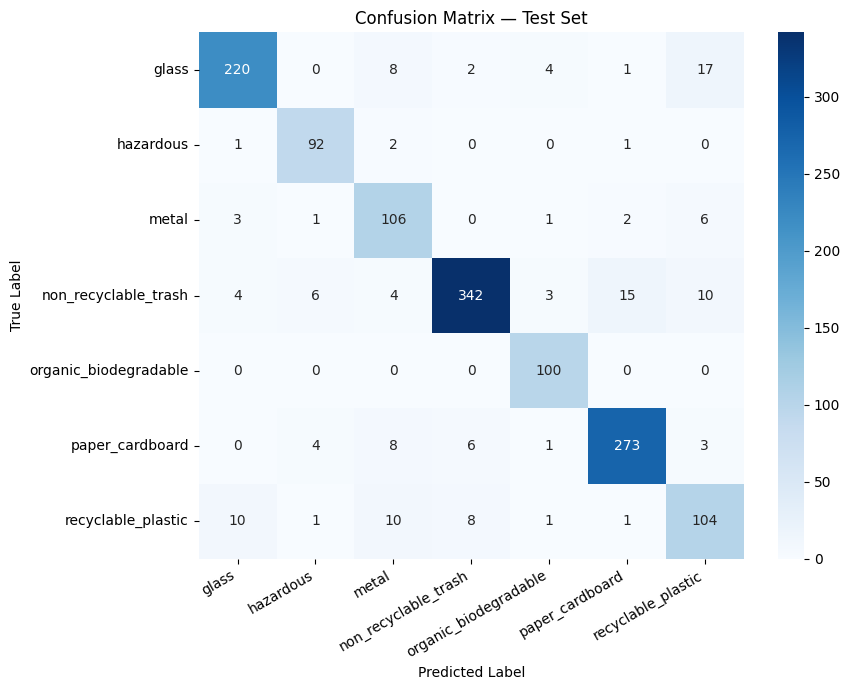

Done! Confusion matrix saved.


In [5]:
all_preds  = []
all_labels = []

print("Running on test set...")
with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images   = images.to(device)
        outputs  = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        if (i + 1) % 10 == 0:
            print(f"  Batch {i+1}/{len(test_loader)} done")

print("\nTEST SET RESULTS")
print("=" * 60)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=3
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap='Blues'
)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrix.png", dpi=120)
plt.show()
print("Done! Confusion matrix saved.")